<a href="https://colab.research.google.com/github/harsh-24-design/Game-Loot/blob/main/Data%20Analysis%20%26%20Visualization%20-%20crop%20yield%20dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# importing necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
!git clone https://github.com/ankitaS11/Crop-Yield-Prediction-in-India-using-ML.git

Cloning into 'Crop-Yield-Prediction-in-India-using-ML'...
remote: Enumerating objects: 19, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 19 (delta 4), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (19/19), 4.70 MiB | 6.36 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [4]:
import os

print(os.listdir())

['.config', 'Crop-Yield-Prediction-in-India-using-ML', 'sample_data']


In [5]:
%cd Crop-Yield-Prediction-in-India-using-ML

/content/Crop-Yield-Prediction-in-India-using-ML


In [6]:
import os
print(os.listdir())

['README.md', 'Crop recommendation .ipynb', 'Crop_Recommendation_Testing_Final.ipynb', 'Crop_recommendation.csv', 'crop_production.csv', 'Crop prediction model .ipynb', 'Data Analysis & Visualization - crop yield dataset.ipynb', '.git']


In [7]:
import pandas as pd

crop_data = pd.read_csv("crop_production.csv")

print(crop_data.head())

                    State_Name District_Name  Crop_Year       Season  \
0  Andaman and Nicobar Islands      NICOBARS       2000  Kharif        
1  Andaman and Nicobar Islands      NICOBARS       2000  Kharif        
2  Andaman and Nicobar Islands      NICOBARS       2000  Kharif        
3  Andaman and Nicobar Islands      NICOBARS       2000  Whole Year    
4  Andaman and Nicobar Islands      NICOBARS       2000  Whole Year    

                  Crop    Area  Production  
0             Arecanut  1254.0      2000.0  
1  Other Kharif pulses     2.0         1.0  
2                 Rice   102.0       321.0  
3               Banana   176.0       641.0  
4            Cashewnut   720.0       165.0  


<b> Exploratory Data Analysis and Data Pre-processing </b>

In [8]:
crop_data.shape

#rows X columns

(246091, 7)

In [9]:
# dataset columns
crop_data.columns

Index(['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area',
       'Production'],
      dtype='object')

In [10]:
# statistical inference of the dataset

crop_data.describe()

,Crop_Year,Area,Production
count,246091.000000,2.460910e+05,2.423610e+05
mean,2005.643018,1.200282e+04,5.825034e+05
std,4.952164,5.052340e+04,1.706581e+07
min,1997.000000,4.000000e-02,0.000000e+00
25%,2002.000000,8.000000e+01,8.800000e+01
50%,2006.000000,5.820000e+02,7.290000e+02
75%,2010.000000,4.392000e+03,7.023000e+03
max,2015.000000,8.580100e+06,1.250800e+09


In [11]:
# viewing unique crops available in the dataset

print(crop_data['Crop'].unique())

['Arecanut' 'Other Kharif pulses' 'Rice' 'Banana' 'Cashewnut' 'Coconut '
 'Dry ginger' 'Sugarcane' 'Sweet potato' 'Tapioca' 'Black pepper'
 'Dry chillies' 'other oilseeds' 'Turmeric' 'Maize' 'Moong(Green Gram)'
 'Urad' 'Arhar/Tur' 'Groundnut' 'Sunflower' 'Bajra' 'Castor seed'
 'Cotton(lint)' 'Horse-gram' 'Jowar' 'Korra' 'Ragi' 'Tobacco' 'Gram'
 'Wheat' 'Masoor' 'Sesamum' 'Linseed' 'Safflower' 'Onion'
 'other misc. pulses' 'Samai' 'Small millets' 'Coriander' 'Potato'
 'Other  Rabi pulses' 'Soyabean' 'Beans & Mutter(Vegetable)' 'Bhindi'
 'Brinjal' 'Citrus Fruit' 'Cucumber' 'Grapes' 'Mango' 'Orange'
 'other fibres' 'Other Fresh Fruits' 'Other Vegetables' 'Papaya'
 'Pome Fruit' 'Tomato' 'Rapeseed &Mustard' 'Mesta' 'Cowpea(Lobia)' 'Lemon'
 'Pome Granet' 'Sapota' 'Cabbage' 'Peas  (vegetable)' 'Niger seed'
 'Bottle Gourd' 'Sannhamp' 'Varagu' 'Garlic' 'Ginger' 'Oilseeds total'
 'Pulses total' 'Jute' 'Peas & beans (Pulses)' 'Blackgram' 'Paddy'
 'Pineapple' 'Barley' 'Khesari' 'Guar seed' 'Moth'


In [12]:
crop_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     246091 non-null  object 
 1   District_Name  246091 non-null  object 
 2   Crop_Year      246091 non-null  int64  
 3   Season         246091 non-null  object 
 4   Crop           246091 non-null  object 
 5   Area           246091 non-null  float64
 6   Production     242361 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 13.1+ MB


In [13]:
# Checking missing values of the dataset in each column
crop_data.isnull().sum()

,0
State_Name,0
District_Name,0
Crop_Year,0
Season,0
Crop,0
Area,0
Production,3730


In [17]:
# Dropping missing values
crop_data = crop_data.dropna()
crop_data

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,Yield
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0,1.594896
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0,0.500000
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0,3.147059
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0,3.642045
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0,0.229167
...,...,...,...,...,...,...,...,...
246086,West Bengal,PURULIA,2014,Summer,Rice,306.0,801.0,2.617647
246087,West Bengal,PURULIA,2014,Summer,Sesamum,627.0,463.0,0.738437
246088,West Bengal,PURULIA,2014,Whole Year,Sugarcane,324.0,16250.0,50.154321
246089,West Bengal,PURULIA,2014,Winter,Rice,279151.0,597899.0,2.141848


In [16]:
#checking
crop_data.isnull().values.any()


np.True_

In [15]:
# Displaying State Names present in the dataset
crop_data.State_Name.unique()

array(['Andaman and Nicobar Islands', 'Andhra Pradesh',
       'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh',
       'Chhattisgarh', 'Dadra and Nagar Haveli', 'Goa', 'Gujarat',
       'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir ', 'Jharkhand',
       'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur',
       'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry',
       'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana ',
       'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal'],
      dtype=object)

In [14]:
# Adding a new column Yield which indicates Production per unit Area.

crop_data['Yield'] = (crop_data['Production'] / crop_data['Area'])
crop_data.head(10)

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,Yield
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0,1.594896
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0,0.500000
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0,3.147059
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0,3.642045
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0,0.229167
5,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Coconut,18168.0,65100000.0,3583.223250
6,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Dry ginger,36.0,100.0,2.777778
7,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Sugarcane,1.0,2.0,2.000000
8,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Sweet potato,5.0,15.0,3.000000
9,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Tapioca,40.0,169.0,4.225000


<i> Visualizing the dataset : </i>

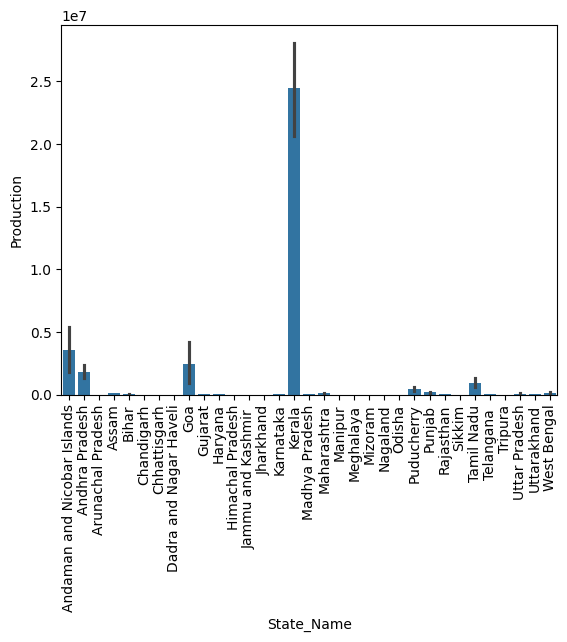

In [24]:

sns.barplot(
    x=crop_data["State_Name"],
    y=crop_data["Production"]
)

plt.xticks(rotation=90)
plt.show()

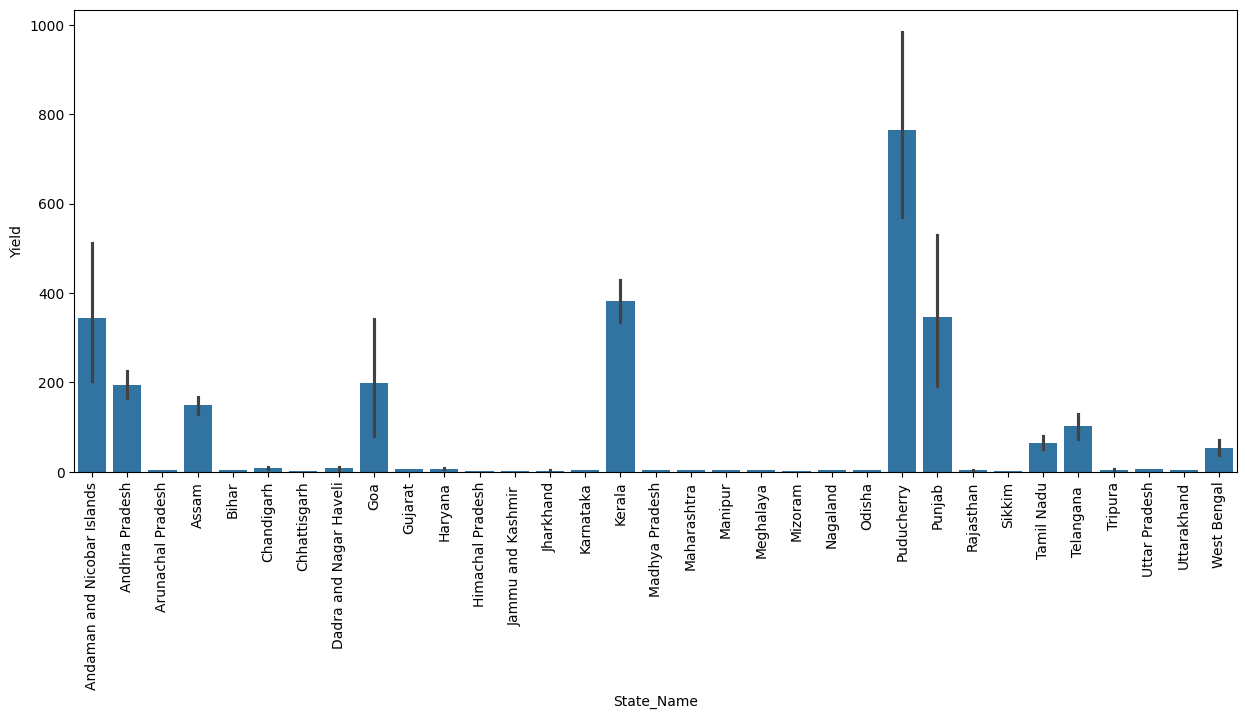

In [25]:
plt.figure(figsize=(15,6))

sns.barplot(
    x=crop_data["State_Name"],
    y=crop_data["Yield"]
)

plt.xticks(rotation=90)

plt.show()

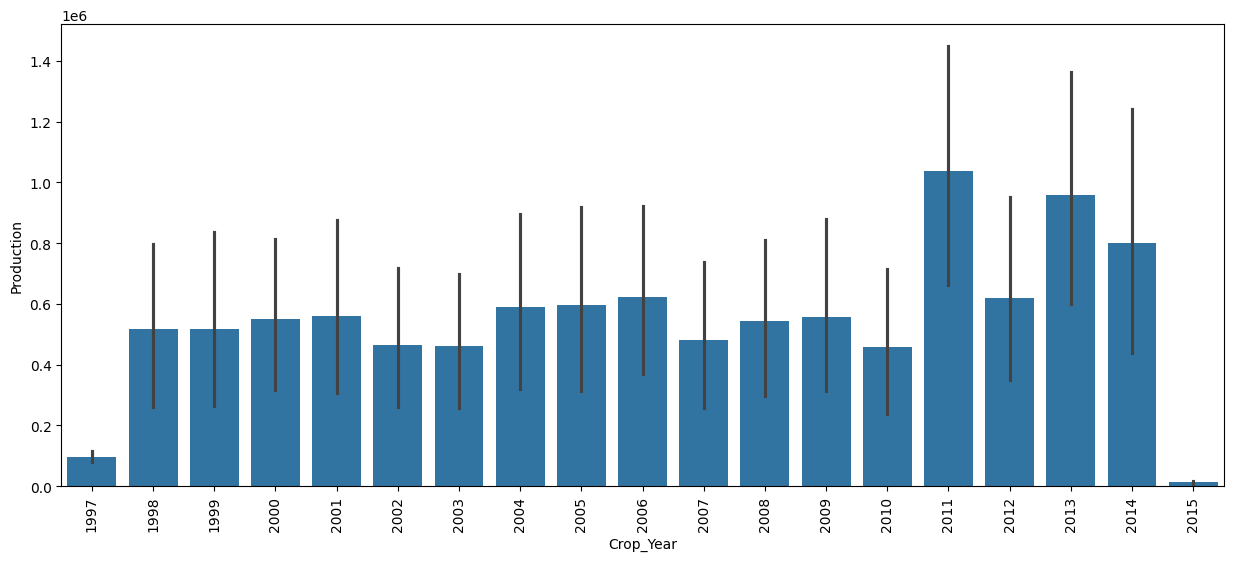

In [26]:
plt.figure(figsize=(15,6))

sns.barplot(
    x=crop_data["Crop_Year"],
    y=crop_data["Production"]
)

plt.xticks(rotation=90)

plt.show()

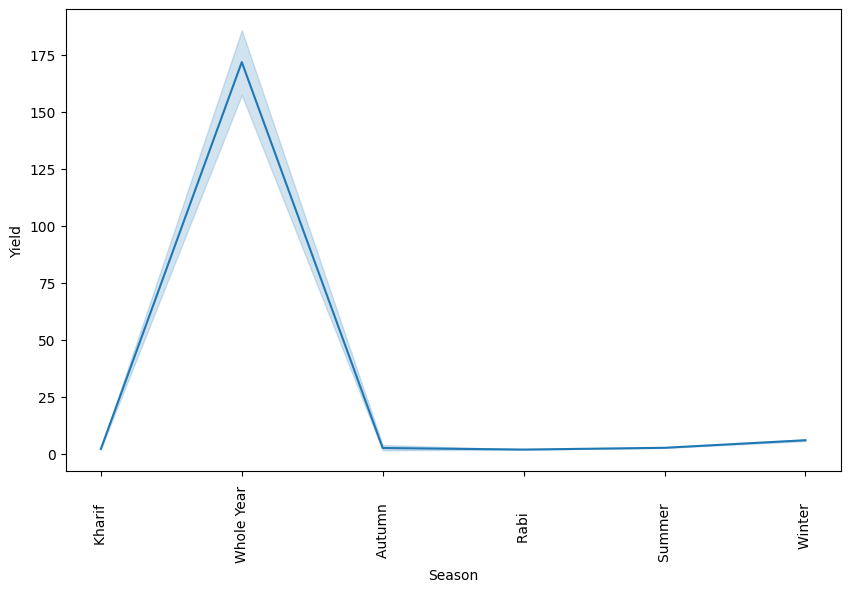

In [27]:
plt.figure(figsize=(10,6))

sns.lineplot(
    x=crop_data["Season"],
    y=crop_data["Yield"]
)

plt.xticks(rotation=90)

plt.show()

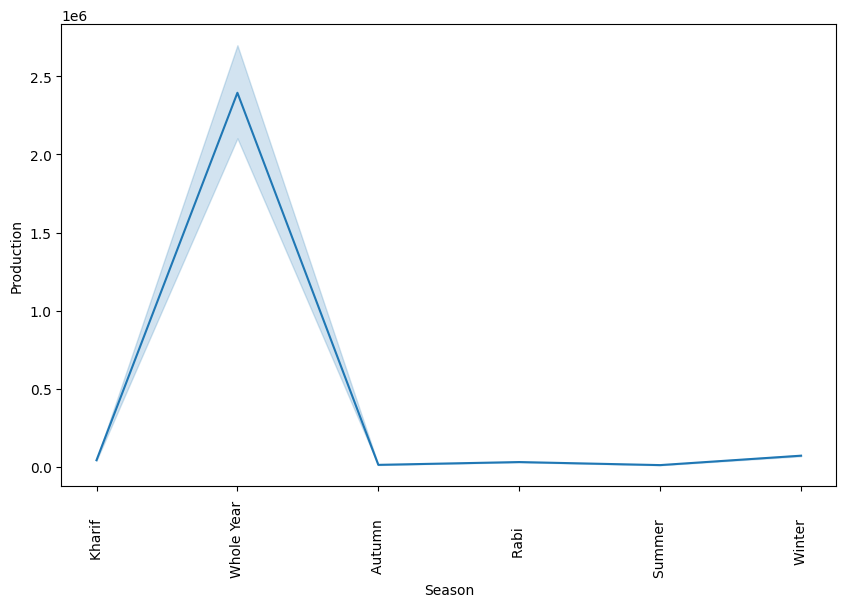

In [28]:
plt.figure(figsize=(10,6))

sns.lineplot(
    x=crop_data["Season"],
    y=crop_data["Production"]
)

plt.xticks(rotation=90)

plt.show()

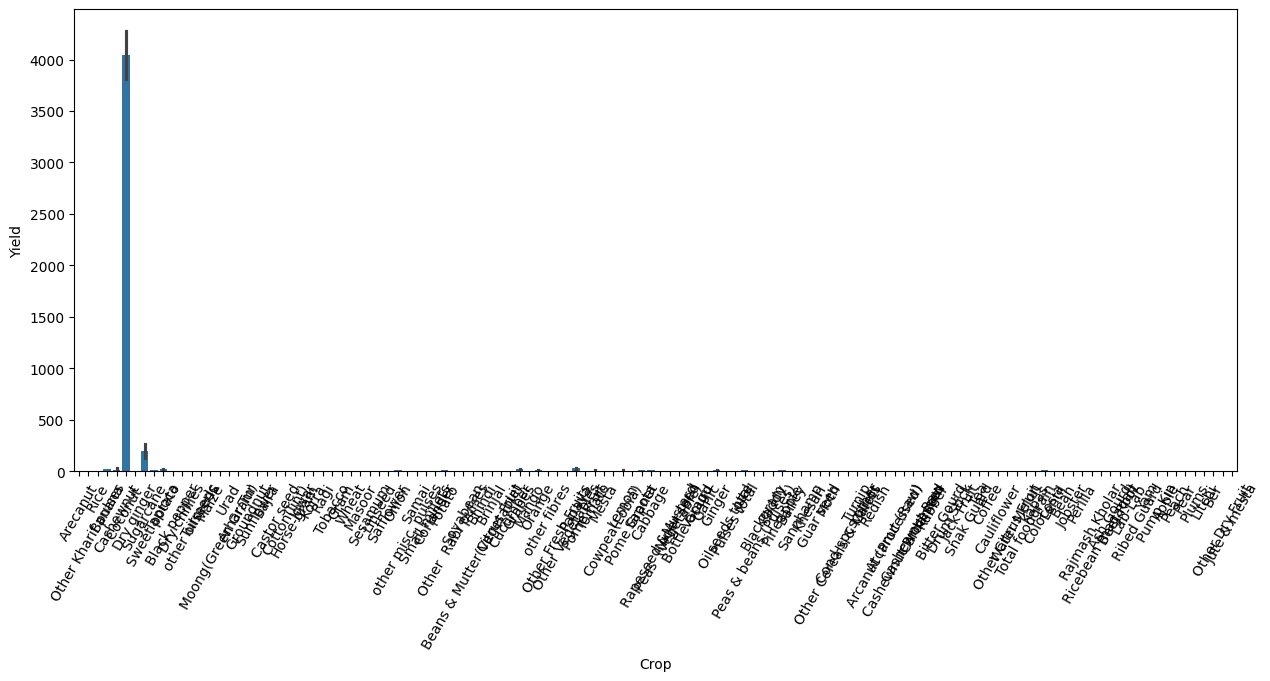

In [29]:
plt.figure(figsize=(15,6))

sns.barplot(
    x=crop_data["Crop"],
    y=crop_data["Yield"]
)

plt.xticks(rotation=60)

plt.show()

In [ ]:
sns.jointplot(
    data=crop_data,
    x="Area",
    y="Production",
    kind="reg"
)

plt.show()

Conclusions Obtained from the dataset:

1. Kerela is the largest producer of crop in India.
2. Production per unit area (Yield ) of Puducherry is maximum.
3. In the year 2011, crop yield was maximum.


Analyzing each type of Crop

<B> 1. RICE </B>

In [ ]:
rice_data = crop_data[crop_data["Crop"]=="Rice"]
rice_data

In [ ]:
rice_data.shape

In [ ]:
sns.barplot("Season","Yield",data = rice_data)
plt.xticks(rotation = 90)

In [ ]:
sns.barplot("State_Name","Yield",data=rice_data)
plt.xticks(rotation=90)

In [ ]:
sns.barplot("Crop_Year","Production",data=rice_data)
plt.xticks(rotation=90)

In [ ]:
sns.barplot("Crop_Year","Yield",data=rice_data)
plt.xticks(rotation=90)

In [ ]:
sns.jointplot("Area","Production",data=rice_data,kind="reg")
plt.xticks(rotation=90)

Observations :

1. Rice yield is maximum in Rabi season.
2. Rice yield is maximum in Chandigarh.
3. Rice yield has been growing a little from the year 2009 to 2014.


<B> WHEAT </B>

In [ ]:
wheat_data = crop_data[crop_data["Crop"]=="Wheat"]
wheat_data

In [ ]:
sns.barplot("Season","Yield",data = wheat_data)


In [ ]:
sns.barplot("State_Name","Production",data = wheat_data)
plt.xticks(rotation = 90)

In [ ]:
sns.lineplot("Crop_Year","Yield",data=wheat_data)
plt.xticks(rotation=90)

In [ ]:
sns.jointplot("Area","Production",data=wheat_data,kind="reg")
plt.xticks(rotation=90)

Conclusions obtained :

1. Rice yield is maximum in Rabi season.
2. Rice yield is maximum in Chandigarh.
3. Rice yield has been growing a little from the year 2009 to 2014.



<B> 3. COCONUT <b>

In [ ]:
coconut_data = crop_data[crop_data["Crop"]=="Urad"]
coconut_data

In [ ]:
sns.barplot("Season","Yield",data = coconut_data)

In [ ]:
sns.barplot("State_Name","Yield",data = coconut_data)
plt.xticks(rotation = 90)

In [ ]:
sns.barplot("State_Name","Production",data = coconut_data)
plt.xticks(rotation = 90)

In [ ]:
sns.lineplot("Crop_Year","Yield",data=coconut_data)
plt.xticks(rotation=90)

In [ ]:
sns.jointplot("Area","Production",data=coconut_data,kind="reg")
plt.xticks(rotation=90)

Observations obtained :

1. Andhra Pradesh is the largest producing cocnut states.
2. Production per unit area is higher in Mizoram ans Sikkim.
3. Coconut yield is decreasing in the year 2012 to 2015.



<B> 4. POTATO </B>

In [ ]:
potato_data = crop_data[crop_data["Crop"]=="Potato"]
potato_data

In [ ]:
sns.barplot("Season","Production",data = potato_data)

In [ ]:
sns.barplot("State_Name","Production",data = potato_data)
plt.xticks(rotation = 90)

In [ ]:
sns.lineplot("Crop_Year","Yield",data=potato_data)
plt.xticks(rotation=90)

In [ ]:
sns.jointplot("Area","Production",data=potato_data,kind="reg")
plt.xticks(rotation=90)

Conclusions obtained :

1. Potato is a Rabi crop.
2. West Bengal is the largest producer of potatoes.



<B> 5. ONION </B>

In [ ]:
onion_data = crop_data[crop_data["Crop"]=="Onion"]
onion_data

In [ ]:
sns.barplot("Season","Yield",data = onion_data)

In [ ]:
sns.barplot("State_Name","Production",data = onion_data)
plt.xticks(rotation = 90)

In [ ]:
sns.lineplot("Crop_Year","Yield",data=onion_data)
plt.xticks(rotation=90)

In [ ]:
sns.jointplot("Area","Production",data=onion_data,kind="reg")
plt.xticks(rotation=90)

Observations :

1. Onion is a Rabi crop.
2. Gujrat and Maharastra are the major onion-producing states.


<B> 6. MAIZE </B>

In [ ]:
maize_data = crop_data[crop_data["Crop"]=="Maize"]
maize_data

In [ ]:
sns.barplot("Season","Yield",data = maize_data)

In [ ]:
sns.barplot("State_Name","Production",data = maize_data)
plt.xticks(rotation = 90)

In [ ]:
sns.lineplot("Crop_Year","Yield",data=maize_data)
plt.xticks(rotation=90)

In [ ]:
sns.jointplot("Area","Production",data=maize_data,kind="reg")
plt.xticks(rotation=90)

Observations Obtained -

1. Maize is produced in the autumn season
2. Telangana is the major maize-producing states.
3. There was a sudden decline in maize production from the year 2000.
